In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)


In [2]:
# Load Dataset Directly from GitHub
url = "https://raw.githubusercontent.com/Mehedi752/AI-ML-Lab/refs/heads/main/NN/dataset/diabetes.csv"
df = pd.read_csv(url)

# View First 5 Rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))


Shape of Dataset:
(768, 9)
5 Random Samples:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
438            1       97             70             15        0  18.2   
189            5      139             80             35      160  31.6   
11            10      168             74              0        0  38.0   
500            2      117             90             19       71  25.2   
237            0      179             90             27        0  44.1   

     DiabetesPedigreeFunction  Age  Outcome  
438                     0.147   21        0  
189                     0.361   25        1  
11                      0.537   34        1  
500                     0.313   21        0  
237                     0.686   23        1  
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   P

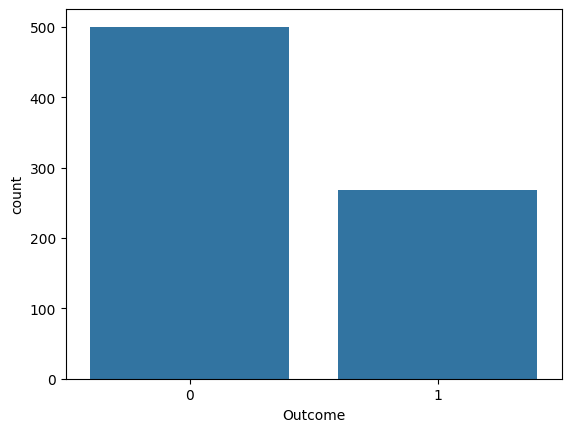

In [4]:
# Class Distribution
sns.countplot(x=df["Outcome"])
plt.show()

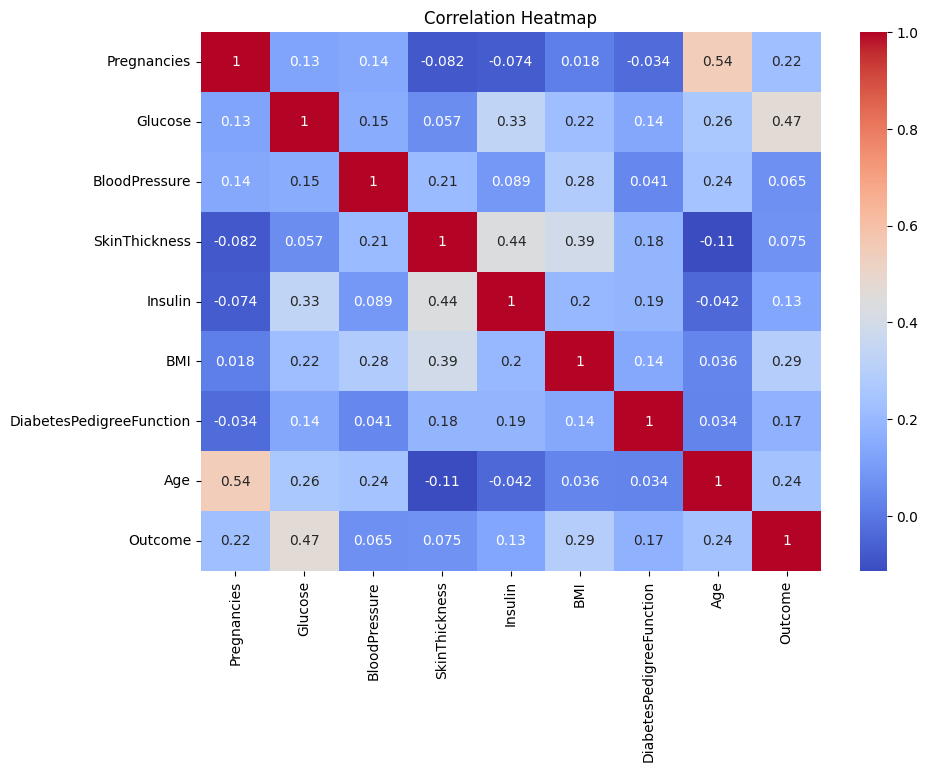

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# Data Preprocessing
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [8]:
# Train Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [9]:
# Convert to Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [10]:
# Data Loader
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [11]:
# Shallow Neural Network
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units, activation):
        super().__init__()

        act = nn.ReLU() if activation == "relu" else nn.Sigmoid()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            act,
            nn.Linear(hidden_units, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [13]:
# Deep Neural Network
class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [14]:
# Training Function
def train_model(model, optimizer, criterion, epochs=100):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()

        epoch_loss = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()

            preds = model(xb)
            loss = criterion(preds, yb)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        model.eval()

        with torch.no_grad():
            train_pred = model(X_train_t)
            val_pred = model(X_val_t)

            train_loss = criterion(train_pred, y_train_t).item()
            val_loss = criterion(val_pred, y_val_t).item()

            train_label = (train_pred >= 0.5).int()
            val_label = (val_pred >= 0.5).int()

            train_acc = accuracy_score(y_train_t, train_label)
            val_acc = accuracy_score(y_val_t, val_label)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

In [15]:
# Train Optimized Shallow Model
input_dim = X_train.shape[1]

shallow_model = ShallowNN(
    input_dim=input_dim,
    hidden_units=16,
    activation="relu"
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    shallow_model.parameters(),
    lr=0.001
)

shallow_history = train_model(
    shallow_model,
    optimizer,
    criterion,
    epochs=100
)

In [16]:
# Train Optimized Deep Model
deep_model = DeepNN(input_dim=input_dim)

optimizer = optim.Adam(
    deep_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

deep_history = train_model(
    deep_model,
    optimizer,
    criterion,
    epochs=150
)

In [18]:
# Evaluation Function
def evaluate_model(model, X_test_t, y_test):
    model.eval()

    with torch.no_grad():
        prob = model(X_test_t).numpy().flatten()

    pred = (prob >= 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, prob),
        "pred": pred,
        "prob": prob
    }

shallow_eval = evaluate_model(shallow_model, X_test_t, y_test)
deep_eval = evaluate_model(deep_model, X_test_t, y_test)

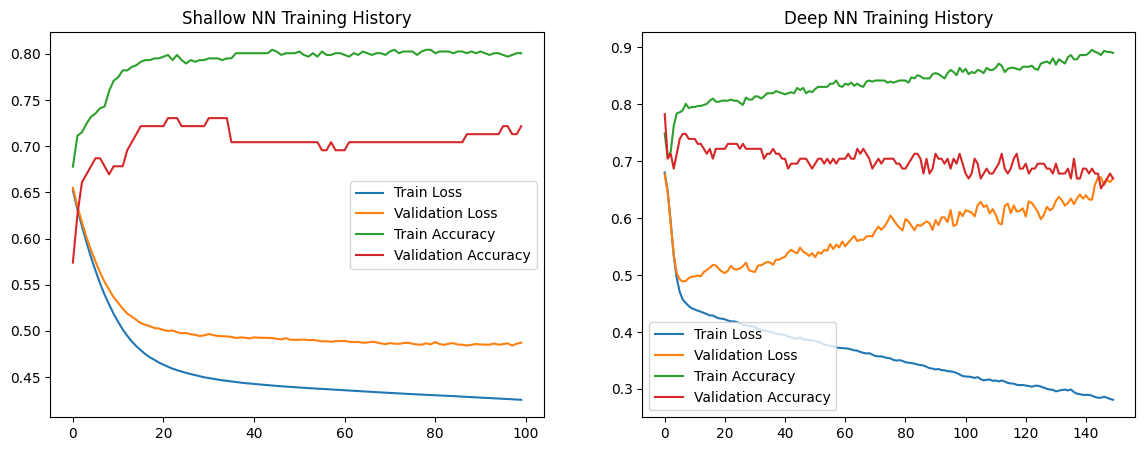

In [19]:
# 1. Training History 2x1
fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(shallow_history["train_loss"], label="Train Loss")
ax[0].plot(shallow_history["val_loss"], label="Validation Loss")
ax[0].plot(shallow_history["train_acc"], label="Train Accuracy")
ax[0].plot(shallow_history["val_acc"], label="Validation Accuracy")
ax[0].set_title("Shallow NN Training History")
ax[0].legend()

ax[1].plot(deep_history["train_loss"], label="Train Loss")
ax[1].plot(deep_history["val_loss"], label="Validation Loss")
ax[1].plot(deep_history["train_acc"], label="Train Accuracy")
ax[1].plot(deep_history["val_acc"], label="Validation Accuracy")
ax[1].set_title("Deep NN Training History")
ax[1].legend()

plt.show()

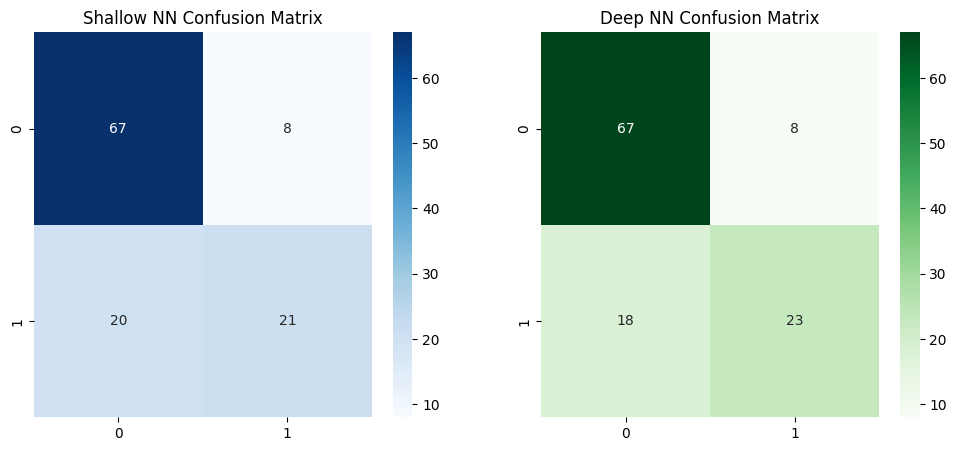

In [20]:
# 2. Confusion Matrix 2x1
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test, shallow_eval["pred"]),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)
ax[0].set_title("Shallow NN Confusion Matrix")

sns.heatmap(
    confusion_matrix(y_test, deep_eval["pred"]),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[1]
)
ax[1].set_title("Deep NN Confusion Matrix")

plt.show()

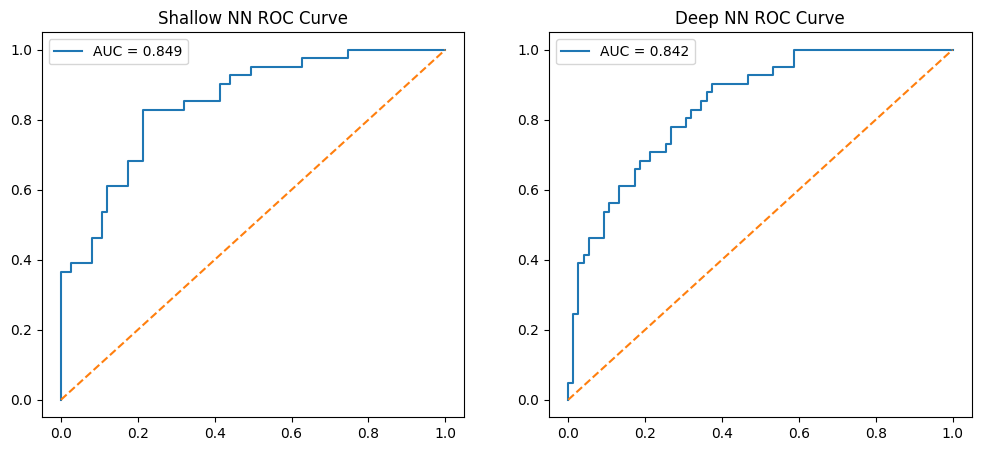

In [21]:
# 3. ROC Curve 2x1
fig, ax = plt.subplots(1, 2, figsize=(12,5))

fpr, tpr, _ = roc_curve(y_test, shallow_eval["prob"])
ax[0].plot(fpr, tpr, label=f"AUC = {shallow_eval['AUC']:.3f}")
ax[0].plot([0,1], [0,1], "--")
ax[0].set_title("Shallow NN ROC Curve")
ax[0].legend()

fpr, tpr, _ = roc_curve(y_test, deep_eval["prob"])
ax[1].plot(fpr, tpr, label=f"AUC = {deep_eval['AUC']:.3f}")
ax[1].plot([0,1], [0,1], "--")
ax[1].set_title("Deep NN ROC Curve")
ax[1].legend()

plt.show()

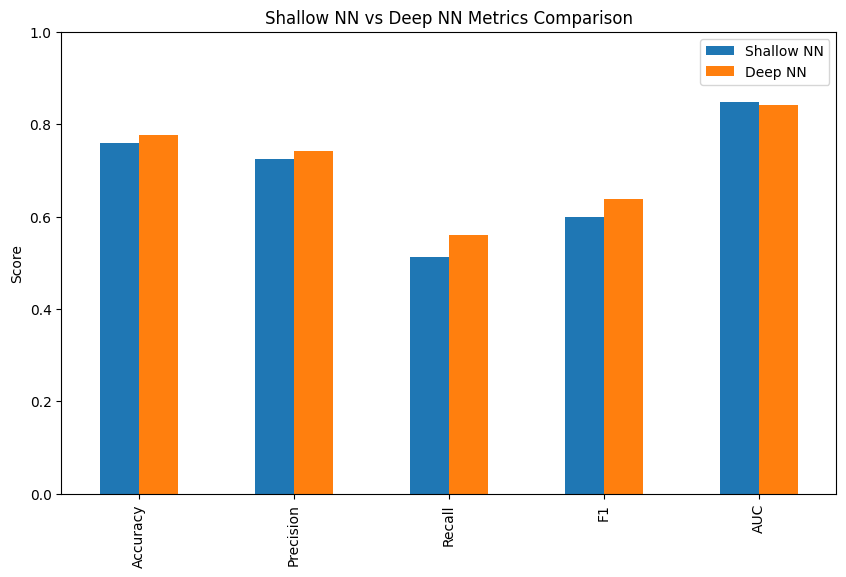

In [22]:
# 4. Metrics Comparison Bar Chart
metrics_df = pd.DataFrame({
    "Shallow NN": [
        shallow_eval["Accuracy"],
        shallow_eval["Precision"],
        shallow_eval["Recall"],
        shallow_eval["F1"],
        shallow_eval["AUC"]
    ],
    "Deep NN": [
        deep_eval["Accuracy"],
        deep_eval["Precision"],
        deep_eval["Recall"],
        deep_eval["F1"],
        deep_eval["AUC"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1", "AUC"])

metrics_df.plot(kind="bar", figsize=(10,6))
plt.title("Shallow NN vs Deep NN Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [23]:
# 5. Network Structure
print("Shallow Neural Network Architecture:")
print(shallow_model)

print("\nDeep Neural Network Architecture:")
print(deep_model)

Shallow Neural Network Architecture:
ShallowNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Deep Neural Network Architecture:
DeepNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [24]:
# Sample Prediction Table
results = pd.DataFrame({
    "Actual": y_test.values,
    "Shallow Prediction": shallow_eval["pred"],
    "Shallow Probability": shallow_eval["prob"],
    "Deep Prediction": deep_eval["pred"],
    "Deep Probability": deep_eval["prob"]
})

results.head(10)

,Actual,Shallow Prediction,Shallow Probability,Deep Prediction,Deep Probability
0,0,0,0.012235,0,0.005581
1,0,0,0.149657,1,0.672894
2,0,0,0.048239,0,0.036153
3,0,0,0.014006,0,0.001268
4,1,1,0.872237,1,0.989281
5,0,0,0.109161,0,0.019792
6,0,0,0.101174,0,0.023555
7,0,1,0.630545,0,0.295557
8,0,0,0.469928,1,0.714321
9,0,0,0.233963,0,0.056754


In [25]:
# Conclusion:
# The Shallow Neural Network used only one hidden layer and produced stable results with lower model complexity. The Deep
# Neural Network used three hidden layers with dropout and L2 regularization, allowing it to learn more complex feature relationships.
# If the deep model achieves higher AUC and F1-score without a large gap between training and validation loss, then the deeper
# architecture is justified. However, if training accuracy is much higher than validation accuracy, the deep model may be
# overfitting. Based on the final metrics and training history, the better model should be selected carefully rather than simply
# choosing the deeper architecture.